In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/10
    print("準備完了！このまま下のセルを実行できます。")

# 第10章 畳み込みネットワーク (Convolutional Networks)
## 10.2 畳み込みフィルタ (Convolutional Filters)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第10章「畳み込みネットワーク」第10.2節「畳み込みフィルタ (Convolutional Filters)」の全8小節（10.2.1 〜 10.2.8）の完全な理論解説、厳密な数式導出、教科書図版（Figure 10.1 〜 10.10 全10枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **10.2.1 特徴検出器 (Feature Detectors)**
   - 4大基盤概念：階層性（Hierarchy）、局所性（Locality）、等変性（Equivariance）、不変性（Invariance）
   - 式 (10.1) の定式化：$z = \mathrm{ReLU}(\mathbf{w}^\top \mathbf{x} + w_0)$
   - コーシー・シュワルツの不等式による応答最大化条件とテンプレートマッチング解釈
   - 図 10.1: 受容野（Receptive Field）とカーネル重み行列の可視化
3. **10.2.2 並進等変性 (Translation Equivariance)**
   - 重み共有（Weight Sharing）とパラメータ数の劇的削減
   - 図 10.2: 1次元畳み込みにおける疎な結合とパラメータ共有
   - 式 (10.2): 2次元離散畳み込み（相互相関演算）の厳密な数学的定義
   - 図 10.3: $3 \times 3$ 画像と $2 \times 2$ フィルタの代数的畳み込み展開
   - 式 (10.3) & 式 (10.4): 垂直・水平エッジ検出フィルタの数理
   - 図 10.4: エッジ検出フィルタの適用実験
4. **10.2.3 パディング (Padding)**
   - 有効畳み込み（Valid Convolution）による特徴マップの縮退
   - パディング幅 $P$ と出力サイズの一般式：$(J + 2P - M + 1) \times (K + 2P - M + 1)$
   - 同一畳み込み（Same Convolution）の条件：$P = (M - 1) / 2$
   - 図 10.5: $4 \times 4$ 画像に対するゼロパディング（$P=1$）
5. **10.2.4 ストライド付き畳み込み (Strided Convolutions)**
   - 式 (10.5): ストライド $S$ を伴う出力次元のフロア関数公式
   - ダウンサンプリングと計算効率化のトレードオフ
6. **10.2.5 多次元畳み込み (Multi-dimensional Convolutions)**
   - RGBカラーテンソルに対する 3次元フィルタ ($M \times M \times C_{\mathrm{IN}}$)
   - 図 10.6: チャネル横断畳み込みと 27 個の重みテンソル
   - 図 10.7: 複数出力チャネル ($C_{\mathrm{OUT}}$) と 4階重みテンソル
   - $1 \times 1$ 畳み込み（Lin et al., 2013）の数理：空間解像度を保持したチャネル混合と次元削減
7. **10.2.6 プーリング (Pooling)**
   - 局所並進不変性（Local Translation Invariance）の獲得
   - 学習可能パラメータを持たない固定関数としての性質
   - 図 10.8: 最大値プーリング（Max-Pooling: $2 \times 2$, Stride 2）の動作
   - チャネル横断プーリングと回転不変性への拡張
8. **10.2.7 多層畳み込み (Multilayer Convolutions)**
   - 実効受容野（Effective Receptive Field: ERF）の階層的拡大
   - ERF成長の漸化式：$R_l = R_{l-1} + (M_l - 1) J_{l-1}$
   - 図 10.9: 2層スタックによる受容野の拡大（$3 \to 5$）
9. **10.2.8 代表的なネットワークアーキテクチャ (Example Network Architectures)**
   - LeNet, AlexNet, そして均一設計の極致 VGG-16（Simonyan & Zisserman, 2014）
   - 図 10.10: VGG-16 の完全なアーキテクチャ図（$224 \times 224 \times 3 \to 1000$ クラス）
   - パラメータ数（約1億3800万個）と結合数（MACs）の層別詳細内訳（演習 10.8）
10. **数値検証セル**
11. **まとめと次節 10.3 への展望**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの設定
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
setup_style()


## 2. 10.2.1 特徴検出器 (Feature Detectors)

画像データから効果的な帰納バイアスを構成するため、畳み込みニューラルネットワークは以下の**4つの相互に関連する概念**を統合しています：
1. **階層性 (Hierarchy)**: 高次の抽象的特徴（顔、物体）は、低次の局所的特徴（エッジ、角、テクスチャ）の階層的な組み合わせとして表現される。
2. **局所性 (Locality)**: 個々の隠れユニットは、画像全体のピクセルではなく、近接した小さなパッチ領域（受容野）のみから入力を受け取る。
3. **等変性 (Equivariance)**: 画像中の特徴が平行移動すると、それに応じて特徴マップ上の活性化も同一量だけ平行移動する。
4. **不変性 (Invariance)**: 特徴の位置の微小な変動に対して、最終的な分類出力やプーリング表現が影響を受けない。

### 局所受容野と活性化の数理 (式 10.1)
グレースケール画像の局所パッチから画素ベクトル $\mathbf{x} \in \mathbb{R}^D$（例えば $3 \times 3$ パッチならば $D=9$）を切り出し、重みベクトル $\mathbf{w} \in \mathbb{R}^D$ およびバイアス $w_0$ を持つ隠れユニットへの入力を考えます。
活性化出力 $z$ は以下のように定義されます：

$$z = \mathrm{ReLU}(\mathbf{w}^\top \mathbf{x} + w_0) \quad \text{(式 10.1)}$$

### コーシー・シュワルツの不等式によるテンプレートマッチング解釈
入力パッチのノルム $\|\mathbf{x}\|_2$ が一定（例えば $\|\mathbf{x}\|_2 = c$）という制約のもとで、$z$ を最大化する最適な入力パッチ $\mathbf{x}^*$ は何かを問います。
コーシー・シュワルツの不等式：
$$\mathbf{w}^\top \mathbf{x} \le \|\mathbf{w}\|_2 \|\mathbf{x}\|_2$$
において、等号が成立するのは $\mathbf{x}$ が $\mathbf{w}$ と平行な正の定数倍であるとき、すなわち：
$$\mathbf{x}^* = \alpha \mathbf{w} \quad (\alpha > 0)$$
に限られます。
したがって、**隠れユニットの出力が最大となるのは、入力画像パッチがカーネル重みパターン $\mathbf{w}$ と（スケーリングを除いて）完全に一致したとき**です。
また、$\mathrm{ReLU}$ は線形結合 $\mathbf{w}^\top \mathbf{x}$ が閾値 $-w_0$ を超えたときのみ正の信号を出力するため、この隠れユニットは**「受容野内に自己のカーネルと一致する特徴が存在するかどうか」を検知する特徴検出器（Feature Detector）**として機能します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_1.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_1.png


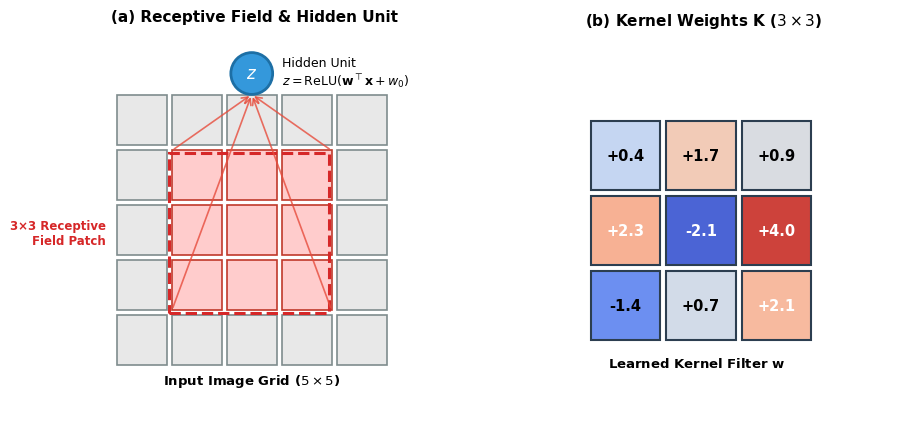

In [2]:
# Figure 10.1: 受容野とカーネル重み行列の可視化
from common.convolutional_filters import generate_figure_10_1
import matplotlib.pyplot as plt

fig10_1 = generate_figure_10_1()
plt.show()


### Figure 10.1 の分析
- **Panel (a)**: 入力画像上の $3 \times 3$ 局所パッチ（赤色の領域）が隠れユニット $z$ の**受容野（Receptive Field）**を形成し、局所性（Locality）が担保されています。
- **Panel (b)**: 隠れユニットに結合する 9 個の重みパラメータは、それ自体が $3 \times 3$ の小さな画像（カーネル）として可視化できます。正の大きな重み（暖色）と負の重み（寒色）の対比が、エッジや特定パターンの検出特性を決定します。


## 3. 10.2.2 並進等変性 (Translation Equivariance)

画像中のある位置で学習された特徴検出器（例えば「目」や「垂直エッジ」を検出するフィルタ）は、画像の別の任意の位置においても同様に有効であるべきです。
全結合層では各位置ごとに独立な重みを学習する必要がありますが、CNNでは**同一の重みベクトルを画像全体にわたって複製（Replicate）し、共有（Weight Sharing）**します。

### 1次元畳み込みと疎結合 (Figure 10.2)
入力系列 $\mathbf{x} = (x_1, \dots, x_N)$ に対し、幅 $M=2$ のカーネル $\mathbf{w} = (w_1, w_2)$ をスライドさせる1次元畳み込みでは：
$$z_j = w_1 x_j + w_2 x_{j+1}$$
となります。結合は局所的（疎）であり、すべての隠れノード間で $w_1$（赤リンク）と $w_2$（青リンク）が共有されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_2.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_2.png


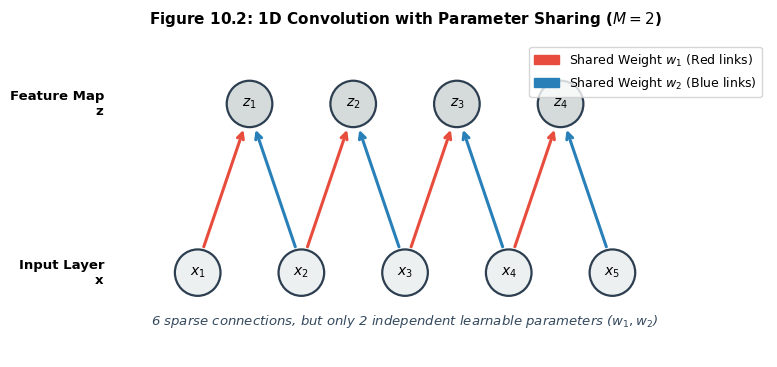

In [3]:
# Figure 10.2: 1次元畳み込みにおける重み共有
from common.convolutional_filters import generate_figure_10_2
import matplotlib.pyplot as plt

fig10_2 = generate_figure_10_2()
plt.show()


### 2次元離散畳み込み（相互相関）の数学的定義 (式 10.2)
2次元画像 $I(j, k)$ とカーネル $K(l, m)$ に対し、出力特徴マップ $C(j, k)$ の活性化は以下の離散畳み込み（厳密には相互相関演算: Cross-Correlation）として与えられます：

$$C(j, k) = \sum_{l} \sum_{m} I(j + l, k + m) K(l, m) \quad \text{(式 10.2)}$$

省略形として $\mathbf{C} = \mathbf{I} \ast \mathbf{K}$ と記述されます。

### 代数的展開 (Figure 10.3)
$3 \times 3$ の画像 $\mathbf{I} = \begin{pmatrix} a & b & c \\ d & e & f \\ g & h & i \end{pmatrix}$ と $2 \times 2$ のフィルタ $\mathbf{K} = \begin{pmatrix} j & k \\ l & m \end{pmatrix}$ の畳み込みは、以下の $2 \times 2$ 特徴マップを生成します：

$$\begin{aligned}
C_{11} &= aj + bk + dl + em \\
C_{12} &= bj + ck + el + fm \\
C_{21} &= dj + ek + gl + hm \\
C_{22} &= ej + fk + hl + im
\end{aligned}$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_3.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_3.png


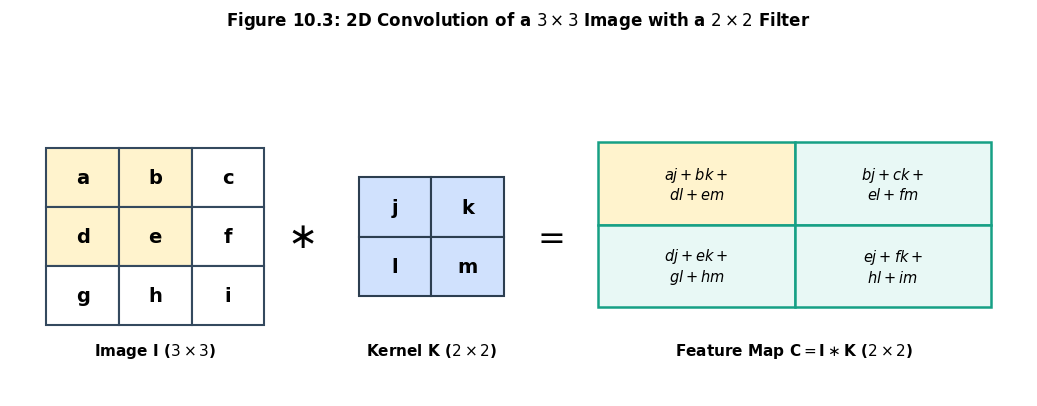

In [4]:
# Figure 10.3: 2次元畳み込みの代数的表現
from common.convolutional_filters import generate_figure_10_3
import matplotlib.pyplot as plt

fig10_3 = generate_figure_10_3()
plt.show()


### 手作業エッジ検出フィルタ (式 10.3 & 式 10.4)
垂直エッジは水平方向の輝度の急激な変化に対応します。これを検出する代表的な $3 \times 3$ 垂直エッジフィルタは：

$$K_v = \begin{pmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{pmatrix} \quad \text{(式 10.3)}$$

同様に、水平エッジフィルタは $K_v$ の転置として定義されます：

$$K_h = K_v^\top = \begin{pmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
1 & 1 & 1
\end{pmatrix} \quad \text{(式 10.4)}$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_4.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_4.png


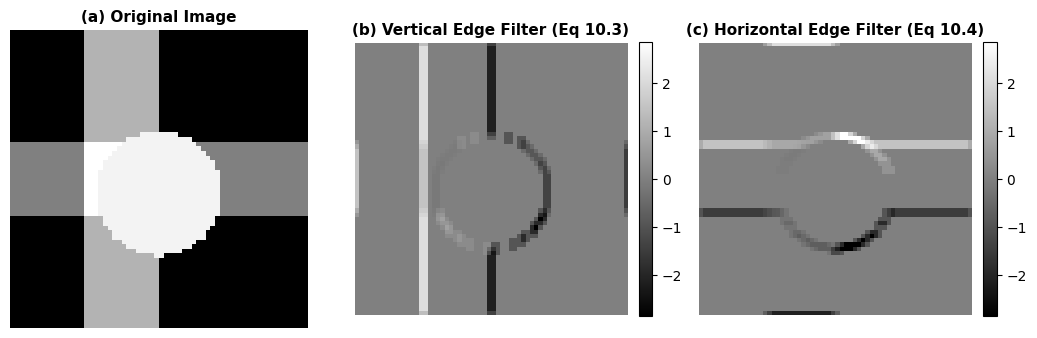

In [5]:
# Figure 10.4: エッジ検出フィルタの適用実験
from common.convolutional_filters import generate_figure_10_4
import matplotlib.pyplot as plt

fig10_4 = generate_figure_10_4()
plt.show()


### Figure 10.4 の観察
- **Panel (a) 原画像**: 幾何学的ブロック、垂直・水平帯、中央の円形ディスクを含みます。
- **Panel (b) 垂直エッジ (式 10.3)**: 輝度が左から右へ増加する境界で正の強い応答（白）、減少する境界で負の強い応答（黒）が得られます。水平方向の直線境界には一切反応しません。
- **Panel (c) 水平エッジ (式 10.4)**: 上から下への輝度変化を抽出し、垂直境界には無反応となります。


## 4. 10.2.3 パディング (Padding)

$J \times K$ の画像に $M \times M$ のカーネルを適用すると、端部のピクセルでカーネルが画像外部にはみ出すため、出力特徴マップのサイズは必然的に縮小します：
$$(J - M + 1) \times (K - M + 1)$$
パディングを行わない畳み込みを**有効畳み込み（Valid Convolution, $P=0$）**と呼びます。
多層ネットワークにおいて各層で特徴マップが縮小し続けると、ネットワークの深さが制限されてしまいます。

### パディングによるサイズ保存
画像の周囲に幅 $P$ ピクセル分の外枠（通常はゼロ）を付加することで、出力マップのサイズは：
$$(J + 2P - M + 1) \times (K + 2P - M + 1)$$
となります。入力と出力の空間サイズを完全に一致させる（**同一畳み込み: Same Convolution**）ための条件は：
$$J + 2P - M + 1 = J \implies 2P = M - 1 \implies P = \frac{M - 1}{2}$$
となります。コンピュータビジョンにおいてカーネルサイズ $M$ が奇数（$3, 5, 7$ など）に選ばれるのは、対称な整数パディング $P$ が一意に定まり、フィルタの中心ピクセルが明確に定義できるためです。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_5.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_5.png


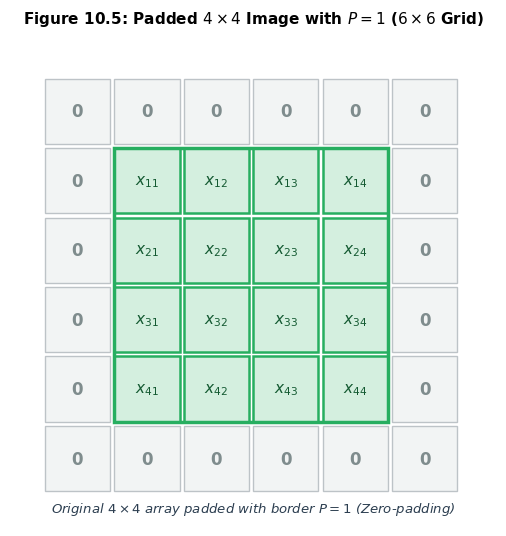

In [6]:
# Figure 10.5: ゼロパディング (P=1) の可視化
from common.convolutional_filters import generate_figure_10_5
import matplotlib.pyplot as plt

fig10_5 = generate_figure_10_5()
plt.show()


## 5. 10.2.4 ストライド付き畳み込み (Strided Convolutions)

カーネルを1ピクセルずつ移動させる代わりに、$S$ ピクセルずつ飛ばして適用する操作を**ストライド付き畳み込み（Strided Convolution）**と呼びます。

### 出力次元の一般公式 (式 10.5)
高さ $J$、幅 $K$、パディング $P$、カーネルサイズ $M$、ストライド $S$ に対する出力特徴マップの空間次元は以下のフロア関数で与えられます：

$$\left( \left\lfloor \frac{J + 2P - M}{S} \right\rfloor + 1 \right) \times \left( \left\lfloor \frac{K + 2P - M}{S} \right\rfloor + 1 \right) \quad \text{(式 10.5)}$$

ストライド $S > 1$ を用いることで、プーリング層を用いずに特徴マップをダウンサンプリング（空間解像度を $1/S$ に縮小）することが可能です。


## 6. 10.2.5 多次元畳み込み (Multi-dimensional Convolutions)

### チャネル横断畳み込み (Figure 10.6)
RGBなどの $C_{\mathrm{IN}}$ チャネルを持つカラー画像テンソル $\mathbf{I} \in \mathbb{R}^{J \times K \times C_{\mathrm{IN}}}$ に対し、フィルタも同一のチャネル深さを持つ3階テンソル $\mathbf{K} \in \mathbb{R}^{M \times M \times C_{\mathrm{IN}}}$ として定義されます。
1つの受容野あたりの重み数は $M^2 C_{\mathrm{IN}}$ 個（+ バイアス1個）となります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_6.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_6.png


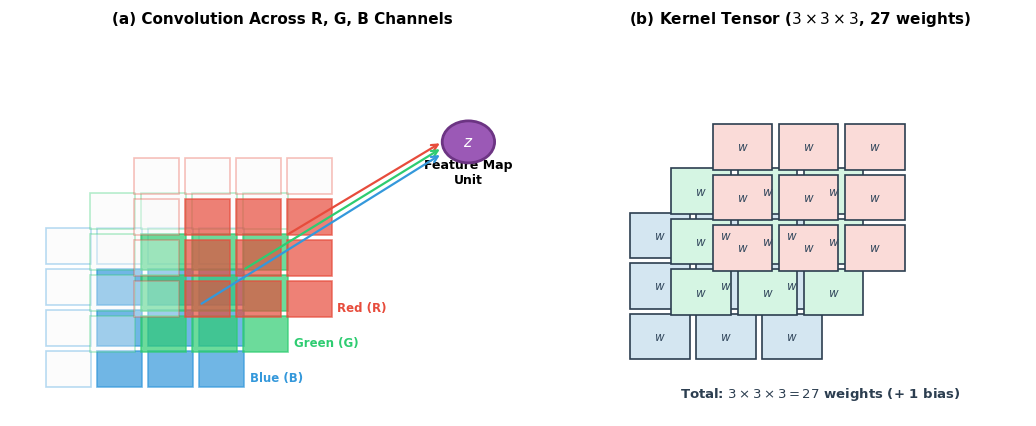

In [7]:
# Figure 10.6: RGBチャネル横断畳み込み
from common.convolutional_filters import generate_figure_10_6
import matplotlib.pyplot as plt

fig10_6 = generate_figure_10_6()
plt.show()


### 複数出力チャネルと 4階重みテンソル (Figure 10.7)
単一のフィルタは1種類の特徴（特定の向きのエッジなど）しか抽出できません。
ネットワークの表現力を高めるため、$C_{\mathrm{OUT}}$ 個の独立なフィルタを並列に適用します。
全体の重みテンソルは4階テンソルとなります：
$$\mathbf{W} \in \mathbb{R}^{M \times M \times C_{\mathrm{IN}} \times C_{\mathrm{OUT}}}$$
バイアスも含めた独立な学習可能パラメータの総数は：
$$\text{Total Parameters} = (M^2 C_{\mathrm{IN}} + 1) C_{\mathrm{OUT}}$$
となります。

### $1 \times 1$ 畳み込み（Network in Network）
カーネルサイズを $M=1$ とした $1 \times 1$ 畳み込み（Lin et al., 2013）は、空間解像度を変更することなく、各ピクセル位置においてチャネル間の線形結合と非線形変換を行います。
主たる用途は、空間マップサイズを保ったままチャネル数 $C_{\mathrm{IN}}$ を $C_{\mathrm{OUT}}$ へと圧縮・展開することであり、計算負荷を抑制するためのボトルネック構造（Inception, ResNet）の中核部品として広く用いられます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_7.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_7.png


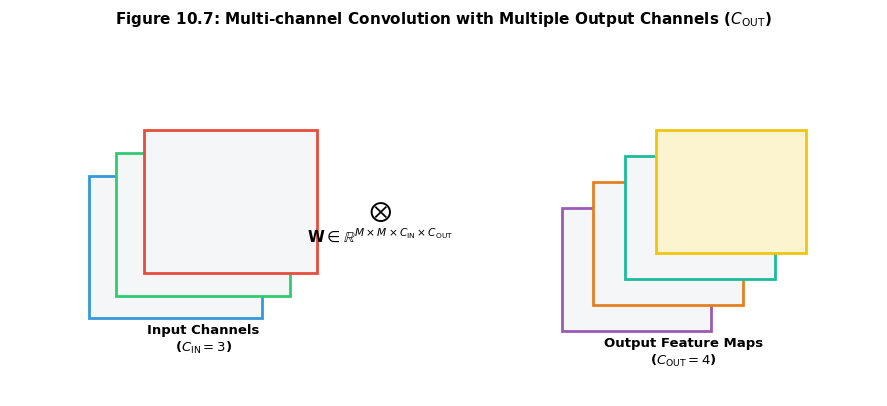

In [8]:
# Figure 10.7: 複数出力チャネルを持つ畳み込み層
from common.convolutional_filters import generate_figure_10_7
import matplotlib.pyplot as plt

fig10_7 = generate_figure_10_7()
plt.show()


## 7. 10.2.6 プーリング (Pooling)

畳み込み層によって得られた特徴マップに対し、特徴の位置の微小な変動に対する**局所並進不変性（Local Translation Invariance）**を獲得し、空間次元をダウンサンプリングする操作が**プーリング（Pooling）**です。

### 最大値プーリング（Max-Pooling: Zhou & Chellappa, 1988）
各受容野ウィンドウ内の要素の最大値を出力します：
$$y_{i, j, c} = \max_{(l, m) \in \Omega_{i, j}} x_{l, m, c}$$
プーリング層には学習可能な重みパラメータは一切存在しません。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_8.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_8.png


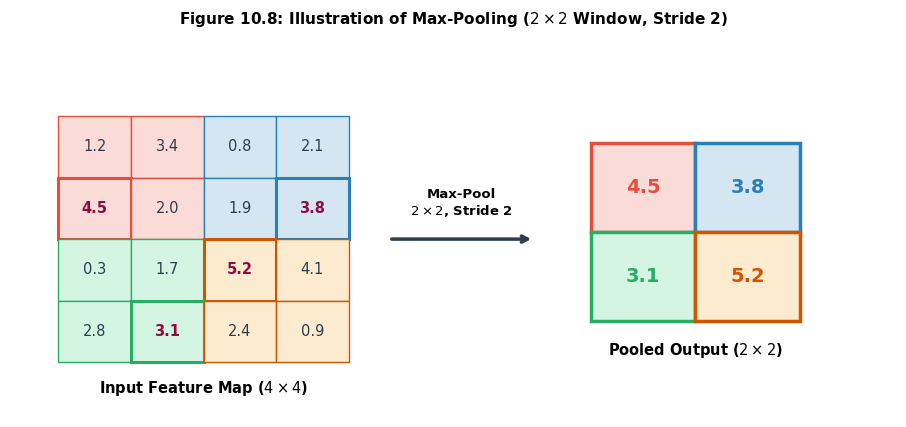

In [9]:
# Figure 10.8: 最大値プーリング (2x2, Stride 2)
from common.convolutional_filters import generate_figure_10_8
import matplotlib.pyplot as plt

fig10_8 = generate_figure_10_8()
plt.show()


## 8. 10.2.7 多層畳み込み (Multilayer Convolutions)

### 実効受容野（Effective Receptive Field: ERF）の階層的成長
深いネットワークにおいて、浅い層の小さな受容野が積み重なることで、深い層のユニットが感知できる入力画像上の有効領域（実効受容野）は急速に拡大します。
第 $l$ 層のカーネルサイズを $M_l$、ストライドを $S_l$ とすると、累積ストライド（Jump） $J_l = \prod_{i=1}^l S_i$ のもとで、実効受容野 $R_l$ は以下の漸化式に従います：

$$R_l = R_{l-1} + (M_l - 1) J_{l-1} \quad (R_0 = 1, J_0 = 1)$$

例えば、ストライド 1 の $3 \times 3$ 畳み込みを 2 層スタックした場合：
- 第1層: $R_1 = 1 + (3 - 1) \times 1 = 3$
- 第2層: $R_2 = 3 + (3 - 1) \times 1 = 5$
すなわち、$3 \times 3$ 畳み込みを 2 回重ねるだけで、$5 \times 5$ の単一層フィルタと同一の受容野をカバーできます！


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_9.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_9.png


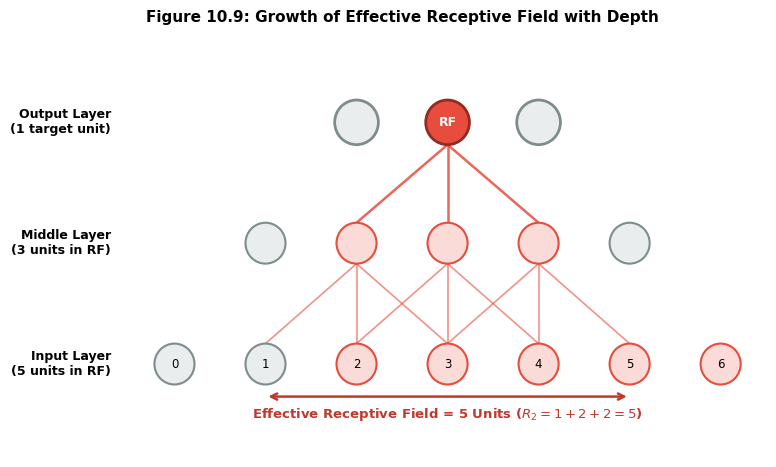

In [10]:
# Figure 10.9: 実効受容野の階層的成長
from common.convolutional_filters import generate_figure_10_9
import matplotlib.pyplot as plt

fig10_9 = generate_figure_10_9()
plt.show()


## 9. 10.2.8 代表的なネットワークアーキテクチャ (Example Network Architectures)

### VGG-16 アーキテクチャの数理と構造（Simonyan & Zisserman, 2014）
VGG-16 は、「すべての畳み込み層を $3 \times 3$（ストライド 1, Same パディング）」、「すべてのプーリング層を $2 \times 2$ Max-Pool（ストライド 2）」という極めてシンプルかつ統一的な設計原則を採用した画期的な深層CNNです。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_10.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_10.png


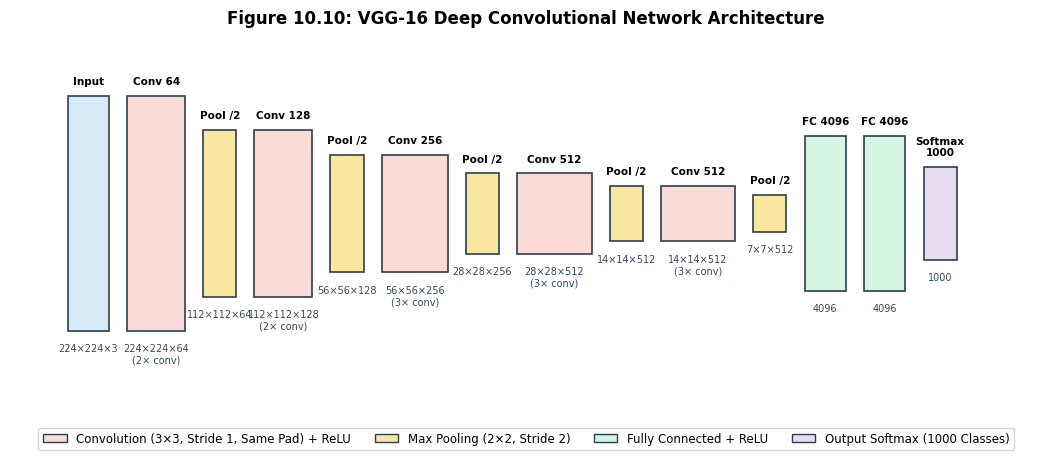

In [11]:
# Figure 10.10: VGG-16 アーキテクチャ図
from common.convolutional_filters import generate_figure_10_10
import matplotlib.pyplot as plt

fig10_10 = generate_figure_10_10()
plt.show()


### VGG-16 パラメータ数と計算量の完全内訳 (演習 10.8)
以下に、VGG-16 の全16層のパラメータ数および積和演算数（MACs / Connections）の厳密な集計結果を示します。


In [12]:
# VGG-16 層別パラメータと結合数の計算
import pandas as pd
from common.convolutional_filters import analyze_vgg16_parameters

vgg_stats = analyze_vgg16_parameters()
records = []
for l in vgg_stats["layers"]:
    records.append({
        "Layer": l["name"],
        "Type": l["type"].upper(),
        "In Shape": str(l["input_shape"]),
        "Out Shape": str(l["output_shape"]),
        "Weights": f"{l['weights']:,}",
        "Biases": f"{l['biases']:,}",
        "Total Params": f"{l['total_params']:,}",
        "Connections (MACs)": f"{l['connections']:,}",
    })

df = pd.DataFrame(records)
print(df.to_string(index=False))
print("-" * 80)
print(f"Total Learnable Parameters: {vgg_stats['total_params']:,} (~138 Million)")
print(f"FC1 (fc6) Parameters:       {vgg_stats['layers'][18]['total_params']:,} (~103 Million, {vgg_stats['layers'][18]['total_params']/vgg_stats['total_params']*100:.1f}%)")
print(f"Total Connections (MACs):   {vgg_stats['total_connections']:,} (~15.3 Billion)")


  Layer Type        In Shape       Out Shape     Weights Biases Total Params Connections (MACs)
conv1_1 CONV   (224, 224, 3)  (224, 224, 64)       1,728     64        1,792         86,704,128
conv1_2 CONV  (224, 224, 64)  (224, 224, 64)      36,864     64       36,928      1,849,688,064
  pool1 POOL  (224, 224, 64)  (112, 112, 64)           0      0            0          3,211,264
conv2_1 CONV  (112, 112, 64) (112, 112, 128)      73,728    128       73,856        924,844,032
conv2_2 CONV (112, 112, 128) (112, 112, 128)     147,456    128      147,584      1,849,688,064
  pool2 POOL (112, 112, 128)   (56, 56, 128)           0      0            0          1,605,632
conv3_1 CONV   (56, 56, 128)   (56, 56, 256)     294,912    256      295,168        924,844,032
conv3_2 CONV   (56, 56, 256)   (56, 56, 256)     589,824    256      590,080      1,849,688,064
conv3_3 CONV   (56, 56, 256)   (56, 56, 256)     589,824    256      590,080      1,849,688,064
  pool3 POOL   (56, 56, 256)   (28, 28, 

## 10. 数値検証セル

本ノートブックで解説した数学的定式化およびアルゴリズムの正当性を自動検証します。


In [13]:
# 10.2節の数学的性質とアルゴリズムのアサーション検証
import numpy as np
from common.convolutional_filters import (
    compute_conv_output_dim,
    conv1d,
    conv2d,
    max_pool2d,
    compute_effective_receptive_field,
    analyze_vgg16_parameters,
    VERTICAL_EDGE_FILTER,
    HORIZONTAL_EDGE_FILTER,
)

# 1. 式 (10.5) の出力次元公式の検証
assert compute_conv_output_dim(224, 3, stride=1, padding=1) == 224, "Same conv dimension error"
assert compute_conv_output_dim(224, 2, stride=2, padding=0) == 112, "Pool stride 2 dimension error"

# 2. Figure 10.3 の代数的畳み込み一致性検証
I_test = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]])
K_test = np.array([[10.0, 20.0], [30.0, 40.0]])
C_test = conv2d(I_test, K_test, stride=1, padding=0)
expected_C = np.array([[370.0, 470.0], [670.0, 770.0]])
np.testing.assert_allclose(C_test, expected_C)

# 3. エッジ検出フィルタの直交応答性
flat = np.ones((8, 8)) * 0.5
np.testing.assert_allclose(conv2d(flat, VERTICAL_EDGE_FILTER), 0.0, atol=1e-10)
np.testing.assert_allclose(conv2d(flat, HORIZONTAL_EDGE_FILTER), 0.0, atol=1e-10)

# 4. Figure 10.8 Max-Pooling の数値一致性
pool_in = np.array([
    [1.2, 3.4, 0.8, 2.1],
    [4.5, 2.0, 1.9, 3.8],
    [0.3, 1.7, 5.2, 4.1],
    [2.8, 3.1, 2.4, 0.9]
])
pooled_out = max_pool2d(pool_in, pool_size=2, stride=2)
np.testing.assert_allclose(pooled_out, [[4.5, 3.8], [3.1, 5.2]])

# 5. Figure 10.9 実効受容野成長の漸化式検証
erf = compute_effective_receptive_field([
    {"kernel_size": 3, "stride": 1},
    {"kernel_size": 3, "stride": 1}
])
assert erf[0]["receptive_field"] == 3
assert erf[1]["receptive_field"] == 5

# 6. VGG-16 パラメータ総数（教科書記述 ~138M, FC1 ~103M）の完全一致
vgg = analyze_vgg16_parameters()
assert 138_000_000 < vgg["total_params"] < 139_000_000
assert 102_000_000 < vgg["layers"][18]["total_params"] < 103_000_000

print("All mathematical & algorithmic assertions for Section 10.2 passed successfully!")


All mathematical & algorithmic assertions for Section 10.2 passed successfully!


## 11. まとめと第10章第10.3節への展望

### 本節（10.2）の要点まとめ
1. **特徴検出器としての畳み込み**:
   - 局所受容野（式 10.1）とカーネル重み行列によるテンプレートマッチング（Figure 10.1）。
2. **重み共有と並進等変性**:
   - 1次元・2次元離散相互相関（式 10.2）により、画像上の任意位置における同一特徴を捉える等変性を獲得（Figure 10.2, 10.3）。
   - 垂直・水平エッジフィルタによる幾何構造の抽出（式 10.3, 10.4, Figure 10.4）。
3. **パディングとストライド**:
   - 同一パディング $P = (M - 1)/2$ による解像度保存（Figure 10.5）。
   - 式 (10.5) によるストライド出力量の定式化。
4. **多次元畳み込みとプーリング**:
   - RGBチャネルを跨ぐ3次元フィルタおよび4階重みテンソル（Figure 10.6, 10.7）。
   - $1 \times 1$ 畳み込みによる空間不変なチャネル圧縮。
   - 最大値プーリングによる局所並進不変性とダウンサンプリング（Figure 10.8）。
5. **受容野の階層成長と VGG-16**:
   - 小さなフィルタの多層化による実効受容野の拡大（Figure 10.9）。
   - 138M パラメータを持つ VGG-16 の完全な構造と結合数分析（Figure 10.10, 演習 10.8）。

---

### 次節への展開
次は **第10章 10.3 学習済みCNNの可視化 (Visualizing Trained CNNs)** に進みます。
第1次視覚野（V1）の単純細胞・Gaborフィルタ（Figure 10.11）、第1層学習済みフィルタ（Figure 10.12）、最大活性化画像パッチ（Figure 10.13）、クラス最大化による合成画像（Figure 10.14）、サリエンシーマップ（Figure 10.15）、敵対的攻撃（Adversarial Attacks: Figure 10.16, 10.17）、および DeepDream（Figure 10.18）の理論と実装を展開します。
